<a href="https://colab.research.google.com/github/blancavazquez/Programa-intensivo-2026-Modulo3/blob/main/notebooks/1_Perceptr%C3%B3n_simple_PRACTICA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Programa Intensivo en Ciencia de Datos de los Fundamentos al Deep Learning**


## **Módulo 3**: *Redes Neuronales Artificiales*

## **Objetivo de esta Notebook**: Construir ejemplos de Perceptrón simple, Perceptrón multivariable y Perceptrón multivariable con múltiples salidas (capa de neuronas) con sus funciones de activación y visualizando sus fronteras de decisión. Esta libreta está inspirada del material desarrolado por el Ing. Gabriel Carcedo, estudiante del PCIC, IIMAS.


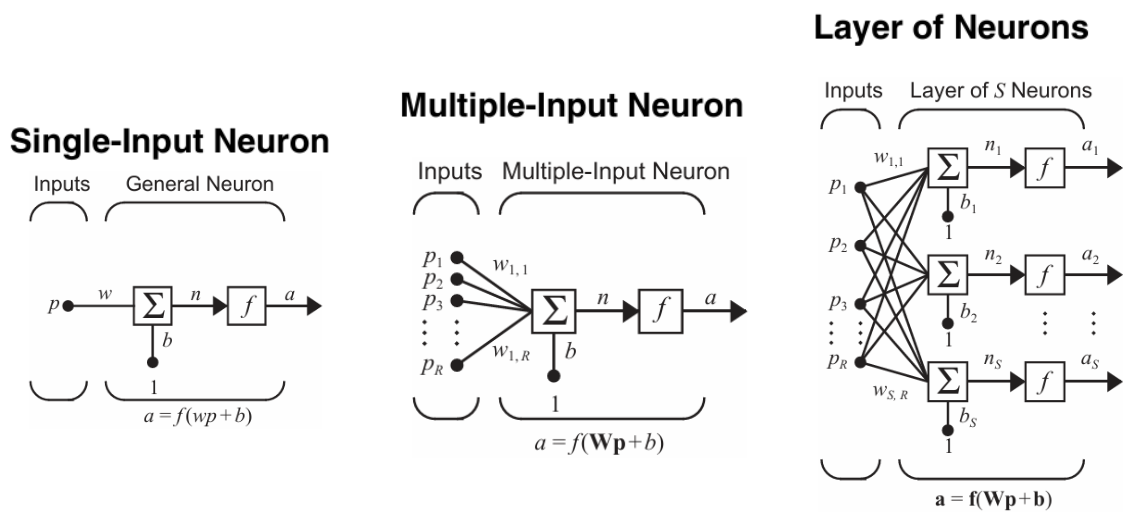

*Recuperado de*: **Hagan M, Demuth H, Beale M, De Jesús O** (2014). *Neural Network Design 2nd Ed*.

# Paquetes y Librerías 📚

In [ ]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import pandas as pd

# Funciones de activación o de transferencia 📈

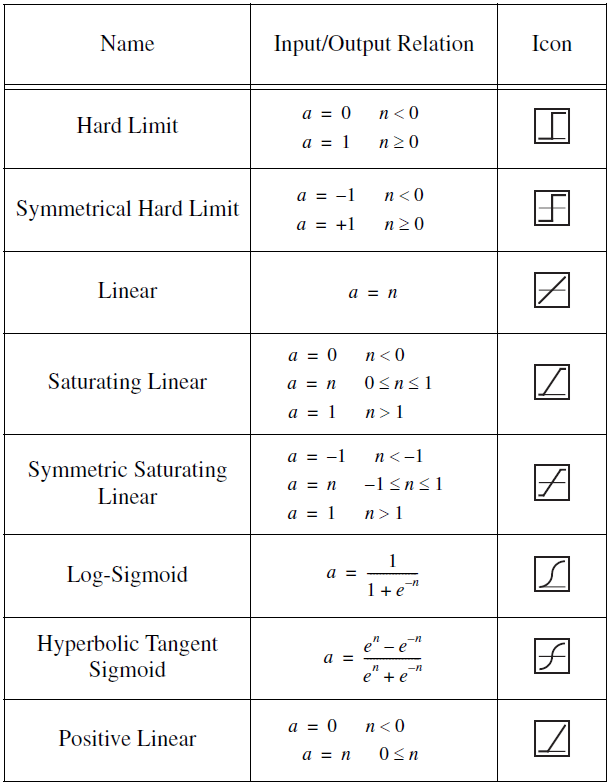

*Recuperado de*: **Hagan M, Demuth H, Beale M, De Jesús O** (2014). *Neural Network Design 2nd Ed*.

In [ ]:
def step(n):
    return np.where(n >= 0, 1, 0)

def sigmoid(n):
    return 1 / (1 + np.exp(-n))

def tanh(n):
    return np.tanh(n)

def relu(n):
    return np.maximum(0, n)

### Visualizar las funciones

In [ ]:
funciones_activacion = {
    'step': step,
    'sigmoid': sigmoid,
    'tanh': tanh,
    'relu': relu,
}

x = np.linspace(-2,2)
for k,v in funciones_activacion.items():
    plt.plot(x, v(x), lw=3)
    plt.title(k)
    plt.grid(ls='--', c='gray', alpha=0.5)
    plt.show()

---
# **1. Perceptrón Simple**
## 1 entrada, 1 salida
---

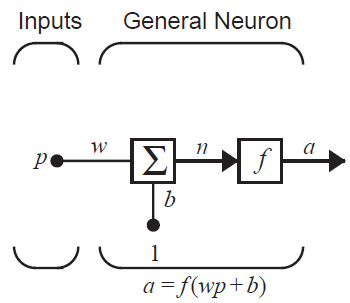


*Recuperado de*: **Hagan M, Demuth H, Beale M, De Jesús O** (2014). *Neural Network Design 2nd Ed*.

# Generar conjunto de datos

In [ ]:
# Número de registros
samples = 20

np.random.seed(1)  # semilla para reproducibilidad

# Generar promedios aleatorios
promedios = np.random.uniform(5, 10, samples)   # promedios de 5 a 10

# Etiquetas
aceptado = (promedios > 7.5).astype(int)   # regla: si promedio > 7.5 → aceptado=1

# Dataset: Usamos promedio -> aceptado
p = promedios.reshape(-1,1) # tamaño de entrada (n,1)
a = aceptado # tamaño de salida (n,)

dataset_df = pd.DataFrame({'Candidatos': np.arange(1, samples+1), 'Promedio Bachillerato': np.round(promedios, 2), 'Dictamen de ingreso': aceptado})
dataset_df.set_index('Candidatos', inplace=True)
dataset_df

# Visualizar el Dataset

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(promedios, aceptado, 'o', color='darkblue', label='Datos')
plt.title('Dataset')
plt.xlabel('Promedio')
plt.ylabel('Clases (Aceptado)')
plt.legend(loc = 'center right')
plt.grid(ls='--', color='grey', alpha=0.5)
plt.yticks([0, 1])
plt.show()

# Inicialización de parámetros

In [ ]:
# Inicializar aleatoriamente los pesos y bias (sesgos)
np.random.seed(10) # Pueden cambiarlo a su consideración
W = np.random.rand()  # peso escalar porque es una sola entrada
b = np.random.rand()
epochs = 10

print("Peso inicial:", W)
print("Bias inicial:", b)

### Función Sumatoria

In [ ]:
def SumMult(p, w, b):
    """
    Calcula n = p*w + b
    p : vector de entradas (n,1)
    w : peso escalar
    b : bias escalar
    """
    a = p * w + b
    return a

# Entrenamiento

In [ ]:
for epoch in range(epochs):
    for i in range(len(p)):
        pi = p[i]
        ai = a[i]

        # print("pi: ", pi, "ai:", ai) ¿Qué es pi y ai?

        # Paso hacia adelante
        n = SumMult(pi, W, b)
        a_hat = step(n) # salida predicha

        # Cálculo del error
        error = ai - a_hat

        # Actualización de pesos
        W += error * pi
        b += error

# Ver al Perceptrón 🔎

In [ ]:
# Rango de valores para el eje x (promedios)
x_vals = np.linspace(5, 10)

# Cálculo de la frontera de decisión
y_vals = -(W * x_vals + b)

# Graficación
plt.figure(figsize=(8, 6))
plt.plot(promedios, aceptado, 'o', color='black')
plt.plot(x_vals, y_vals, 'b--', label="Frontera de decisión", lw=5, alpha=0.7)
plt.xlabel("Promedio")
plt.ylabel("Clases (Aceptación)")
plt.grid(ls='--', color='grey', alpha=0.5)
plt.legend()
plt.yticks([0, 1])
plt.title("Frontera de decisión del perceptrón")
plt.show()


# **¿Qué hicimos?** 🤔

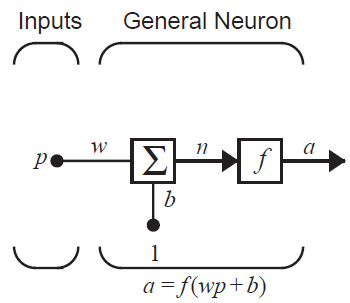


*Recuperado de*: **Hagan M, Demuth H, Beale M, De Jesús O** (2014). *Neural Network Design 2nd Ed*.

# **Ejercicio 1**: Evaluación con población no vista (conjunto de prueba)

Evaluaremos el modelo utilizando datos de estudiantes no vistos durante el entrenamiento. Lo que debes realizar es:

* Utiliza el modelo entrenado y evalúa con un nuevo estudiante que obtuvo 8.5 en su promedio de bachillerato, ¿cuál sería el dictamen?

* Nuevamente utiliza el modelo, y ahora evalúa con un estudiante que obtuvo 5 de promedio, ¿cuál sería el dictamen?


In [ ]:
# Nuevo estudiante
promedio_bachillerato = 8.5
datos = #sugerencia crea un arreglo
prediccion = #aquí escribe tu función
print("prediccion: ", prediccion)
print(f"Promedio: {promedio_bachillerato:.2f} → {'Aceptado' if prediccion==1 else 'No aceptado'}")


In [ ]:
# Nuevo estudiante
promedio_bachillerato = 5
datos = #sugerencia crea un arreglo
prediccion = #aquí escribe tu función
print("prediccion: ", prediccion)
print(f"Promedio: {promedio_bachillerato:.2f} → {'Aceptado' if prediccion==1 else 'No aceptado'}")

---
# **2. Perceptrón simple con múltiples entradas**
## R entradas, 1 salida
---

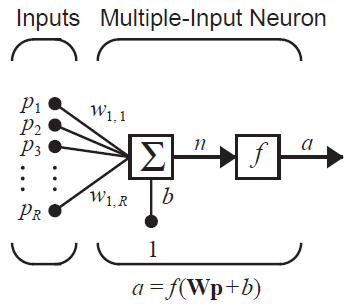

*Recuperado de*: **Hagan M, Demuth H, Beale M, De Jesús O** (2014). *Neural Network Design 2nd Ed*.

# Generar el dataset

In [ ]:
# Número de registros
samples = 20

np.random.seed(10)  # semilla para reproducibilidad

# Generar promedios aleatorios
promedios = np.random.uniform(5, 10, samples)   # promedios de 5 a 10
calif_examen  = np.random.uniform(5, 10, samples)     # resultados de examen de 50 a 100

# Etiquetas
aceptado = ((promedios > 7.5) & (calif_examen > 7)).astype(int)   # regla: si promedio > 7.5 y examen > 70 → aceptado=1

# Dataset de múltiples entradas
p = np.column_stack((promedios, calif_examen))  # (n,2)
a = aceptado # (n,)

dataset_df = pd.DataFrame({'Candidato': range(1, samples+1), 'Promedio Bachillerato': np.round(promedios, 2), 'Examen conocimientos': np.round(calif_examen, 2), 'Dictamen de ingreso': aceptado})
dataset_df.set_index('Candidato', inplace=True)
dataset_df

# Visualizar el Dataset

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(promedios[aceptado == 1], calif_examen[aceptado == 1], 'o', color='green', label='Aceptado')
plt.plot(promedios[aceptado == 0], calif_examen[aceptado == 0], 'o', color='red', label='Rechazado')
plt.title('Dataset')
plt.xlabel('Promedio')
plt.ylabel('Examen')
plt.grid(ls='--', color='grey', alpha=0.5)
plt.legend(loc='lower center')
plt.show()

# Inicialización de paramétros

In [ ]:
# Generar MATRIZ de pesos y sesgo
np.random.seed(10)
W = np.random.rand(2)   # vector de 2 pesos (R)
b = np.random.rand()    # sesgo escalar
epochs = 1000
lr = 0.5

print("Pesos iniciales:", W)
print("Bias inicial:", b)

### Notar que los pesos ahora son un vector (1, 2) ❗

### Función sumatoria

In [ ]:
def SumMult(p, W, b):
    """
    Calcula n = p*W + b
    p : vector de entradas (n, d)  -> cada fila es un ejemplo
    W : vector de pesos (d,)
    b : bias escalar
    """
    return np.dot(p, W) + b # PRODUCTO PUNTO

# Entrenamiento

In [ ]:
for epoch in range(epochs):
    for i in range(len(p)):
        pi = p[i]
        ai = a[i]

        #print("pi: ", pi) ¿ahora qué es pi?
        # print("ai: ", ai) ¿qué es ai?

        # Paso hacia adelante
        n = SumMult(pi, W, b)
        a_hat = step(n) # salida predicha

        # Cálculo del error
        error = ai - a_hat

        # Actualización de pesos
        W += lr * error * pi
        b += lr * error


# Ver al Perceptrón 🔎

In [ ]:
# Rango de valores para el eje x
x_vals = np.linspace(5, 10)

# Cálculo de la frontera de decisión
w1, w2 = W
y_vals = -(w1 * x_vals + b) / w2

# Graficación
plt.figure(figsize=(6, 4))
plt.scatter(promedios[a == 1], calif_examen[a == 1], color='green', label='Aceptado')
plt.scatter(promedios[a == 0], calif_examen[a == 0], color='red', label='Rechazado')
plt.plot(x_vals, y_vals, 'b--', label="Frontera de decisión", lw=3, alpha=0.7)
plt.xlabel("Promedio")
plt.ylabel("Examen")
plt.grid(ls='--', color='grey', alpha=0.5)
plt.legend()
plt.ylim(5, 10)
plt.xlim(5, 10)
plt.title("Frontera de decisión del perceptrón")
plt.show()


# **Ejercicio 2:**
Utiliza el modelo entrenado y evalúa con un nuevo estudiante que obtuvo 8.0 en su promedio de bachillerato y 7 en su calificación de examen, ¿cuál sería el dictamen?

In [ ]:
# Nuevo estudiante
promedio_bachillerato = 8
calificacion_examen = 7

datos = #sugerencia crea un arreglo
prediccion = #aquí tu función
print("prediccion: ", prediccion)
print(f"Promedio: {promedio_bachillerato:.2f} Examen : {calificacion_examen:.2f}→ {'Aceptado' if prediccion==1 else 'No aceptado'}")

---
# **Ejercicio 3**: Agrega una nueva variable de entrada
---
>### a. Crear un arreglo de valores para las actividades extracurriculares llamado: '**extracurricular**' (*nueva variable de entrada*).
>### b. Los valores deben ser enteros en el rango: 0 - 10.
>### c. El criterio de las etiquetas es el siguiente:
>```
># aceptado = ((promedios > 7.5) & (calif_examen > 7) & (extracurricular >= 5)).astype(int)
>```
>### d. Inicializa los parámetros (pesos, sesgos, etc.).
>### e. Entrena el Perceptrón.
>### f. Visualiza la frontera de decisión.
---





In [ ]:
# 1. Crea tu arreglo de datos aquí!

In [ ]:
#2. Genera tu matriz de pesos

In [ ]:
#3. Entrena tu modelo aquí!

In [ ]:
# Visualización (gratis!)
import plotly.graph_objects as go

# Extraer pesos
w1, w2, w3 = W
b0 = b

# Crear rango para x (promedios) y y (examen)
x_vals = np.linspace(5, 10, 20)
y_vals = np.linspace(5, 10, 20)
xx, yy = np.meshgrid(x_vals, y_vals)

# Calcular la frontera de decisión empleando los pesos entrenados
zz = -(w1*xx + w2*yy + b0) / w3

# Crear figura 3D
fig = go.Figure()

# Nube de puntos (Aceptados y Rechazados)
fig.add_trace(go.Scatter3d(
    x=promedios[a==1], y=calif_examen[a==1], z=extracurricular[a==1],
    mode="markers",
    marker=dict(size=5, color="green"),
    name="Aceptado"
))
fig.add_trace(go.Scatter3d(
    x=promedios[a==0], y=calif_examen[a==0], z=extracurricular[a==0],
    mode="markers",
    marker=dict(size=5, color="red"),
    name="Rechazado"
))

# Plano de decisión
fig.add_trace(go.Surface(
    x=xx, y=yy, z=zz,
    opacity=0.5,
    colorscale="Blues",
    showscale=False,
    name="Frontera de decisión"
))

# Configuración de ejes
fig.update_layout(
    title="Frontera de decisión del perceptrón con 3 entradas",
    scene=dict(
        xaxis=dict(title="Promedio", range=[5, 10]),
        yaxis=dict(title="Examen", range=[5, 10]),
        zaxis=dict(title="Extracurricular", range=[0, 10]),
        aspectmode="cube"
    )
)

fig.show()

#Ejercicio 4

Utiliza el modelo entrenado y evalúa con un nuevo estudiante que obtuvo 8.0 en su promedio de bachillerato, 7 en su calificación de examen y 6 en extracurricular, ¿cuál sería el dictamen?

In [ ]:
# Nuevo estudiante
promedio_bachillerato = 8.0
calificacion_examen = 7
extracurricular = 6

datos = # se sugiere usar una arreglo
prediccion = # escribe tu función aquí!

print("prediccion: ", prediccion)
print(f"Promedio: {promedio_bachillerato:.2f} Examen : {calificacion_examen:.2f} Examen : {extracurricular:.2f}→ {'Aceptado' if prediccion==1 else 'No aceptado'}")